In [8]:
import pandas
import numpy
from energiapy.components.temporal_scale import TemporalScale
from energiapy.components.resource import Resource, VaryingResource
from energiapy.components.process import Process, VaryingProcess
from energiapy.components.material import Material
from energiapy.components.location import Location
from energiapy.components.network import Network
from energiapy.components.scenario import Scenario
from energiapy.components.transport import Transport
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.plot import plot_results, plot_scenario
from energiapy.plot.plot_results import CostY, CostX
from energiapy.model.solve import solve
from itertools import product



from energiapy.components.result import Result
import pandas
from itertools import product
from matplotlib import rc
import matplotlib.pyplot as plt
from energiapy.model.solve import solve
from energiapy.plot.plot_results import CostY, CostX
from energiapy.components.location import Location
from energiapy.plot import plot_results, plot_scenario
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.model.bounds import CapacityBounds
from energiapy.utils.data_utils import get_data, make_henry_price_df, remove_outliers, load_results
from energiapy.components.transport import Transport
from energiapy.components.scenario import Scenario
from energiapy.components.network import Network
from energiapy.components.location import Location
from energiapy.components.material import Material

from energiapy.conversion.photovoltaic import solar_power_output
from energiapy.conversion.windmill import wind_power_output

from energiapy.utils.data_utils import load_results
from energiapy.plot import plot_results, plot_scenario
from energiapy.plot.plot_results import CostY, CostX

ModuleNotFoundError: No module named 'energiapy'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


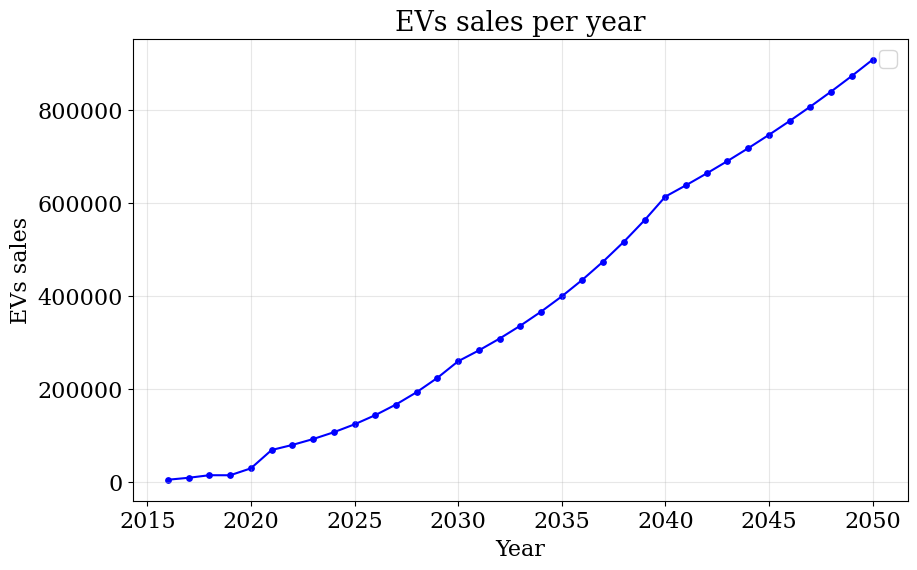

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'y_': [4200.0, 8400.0, 13900.0, 13800.0, 28700.0, 68100.0, 78996.0, 91635.36, 106297.02, 123304.54, 143033.27, 165918.59, 192465.56, 223260.05, 258981.66, 282290.01, 307696.11, 335388.76, 365573.75, 398475.39, 434338.18, 473428.61, 516037.19, 562480.53, 613103.78, 637627.93, 663133.05, 689658.37, 717244.71, 745934.49, 775771.87, 806802.75, 839074.86, 872637.85, 907543.37],
        'x_': [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'blue',
        'label': '',
    }
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('EVs sales per year')
plt.ylabel('EVs sales')
plt.xlabel('Year')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()

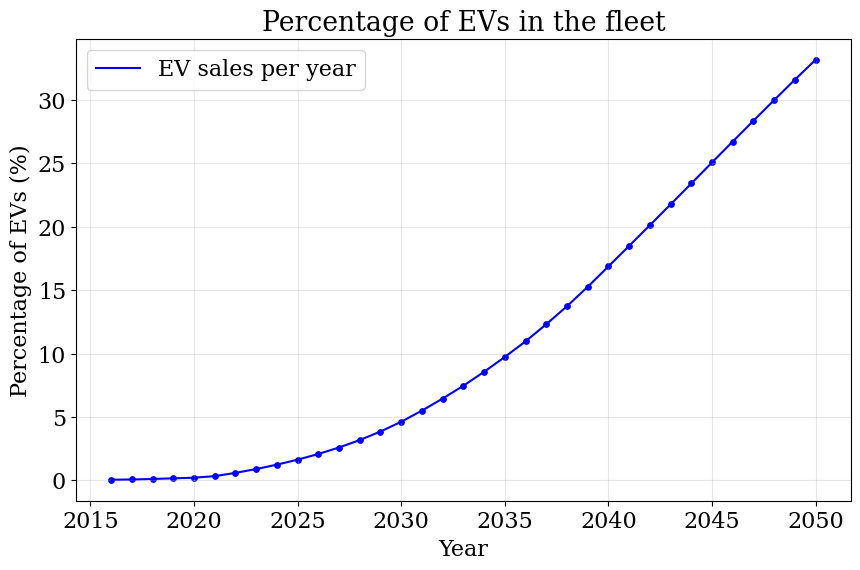

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'y_': [0.05, 0.07, 0.11, 0.16, 0.21, 0.33, 0.59, 0.89, 1.24, 1.63, 2.08, 2.59, 3.18, 3.85, 4.62, 5.5, 6.45, 7.46, 8.56, 9.73, 10.96, 12.31, 13.73, 15.26, 16.87, 18.49, 20.12, 21.76, 23.41, 25.07, 26.72, 28.36, 29.99, 31.6, 33.17],
        'x_': [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'blue',
        'label': 'EV sales per year'
    }
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Percentage of EVs in the fleet')
plt.ylabel('Percentage of EVs (%)')
plt.xlabel('Year')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()

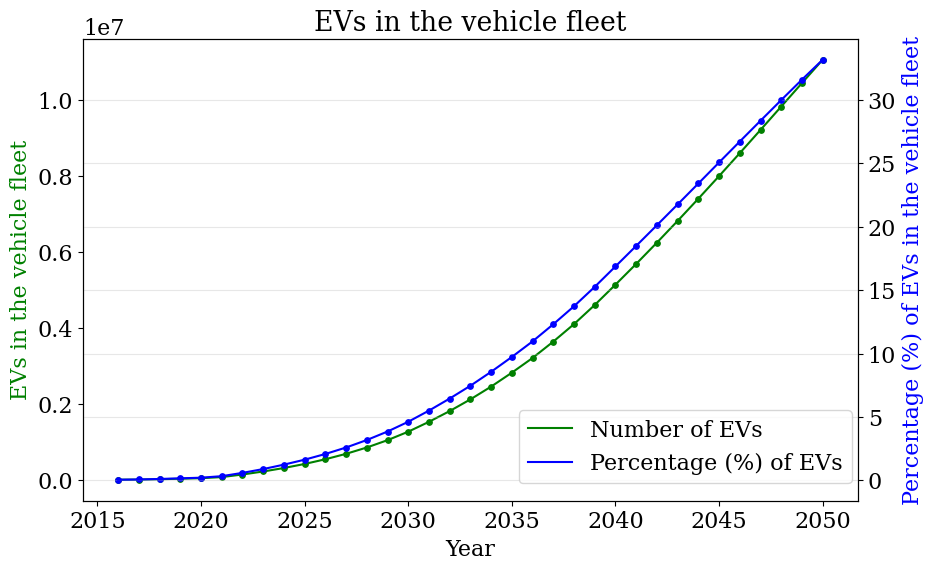

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Data
x = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]
y1 = [11900, 16100, 24500, 38400, 52200, 80900, 149000,227996.00, 319631.36, 425928.38, 549232.92, 692266.18, 858184.77, 1050650.34, 1273910.39, 1532892.06, 1815182.07, 2122878.18, 2458266.95, 2823840.70, 3210416.09, 3640554.26, 4100082.87, 4602320.06, 5136100.59, 5681104.37, 6239736.31, 6811234.00, 7394595.35, 7988535.52, 8591436.74, 9201290.03, 9815627.21, 10431442.02, 11045098.21]
y2 = [0.05, 0.07, 0.11, 0.16, 0.21, 0.33, 0.59, 0.89, 1.24, 1.63, 2.08, 2.59, 3.18, 3.85, 4.62, 5.5, 6.45, 7.46, 8.56, 9.73, 10.96, 12.31, 13.73, 15.26, 16.87, 18.49, 20.12, 21.76, 23.41, 25.07, 26.72, 28.36, 29.99, 31.6, 33.17]

# Plot all lines on the same graph
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot data on the first y-axis
ax1.plot(x, y1, 'g-', label='Number of EVs')
ax1.scatter(x, y1, color='g', s=15)  # Add scatter points
ax1.set_xlabel('Year')
ax1.set_ylabel('EVs in the vehicle fleet', color='g')

# Create a second y-axis and plot data on it
ax2 = ax1.twinx()
ax2.plot(x, y2, 'b-', label='Percentage (%) of EVs')
ax2.scatter(x, y2, color='b', s=15)  # Add scatter points
ax2.set_ylabel('Percentage (%) of EVs in the vehicle fleet', color='b')

# Show plot
plt.title('EVs in the vehicle fleet')
plt.grid(alpha=0.3)
fig.legend(loc='center left', bbox_to_anchor=(0.55, 0.2))
plt.rcdefaults()
plt.show()

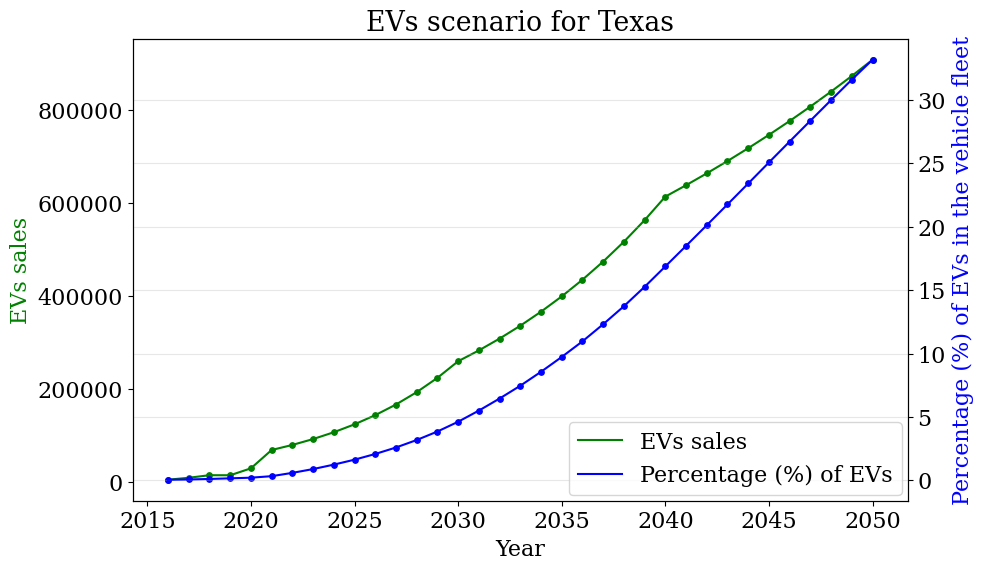

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Data
x = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]
y1 = [4200.0, 8400.0, 13900.0, 13800.0, 28700.0, 68100.0, 78996.0, 91635.36, 106297.02, 123304.54, 143033.27, 165918.59, 192465.56, 223260.05, 258981.66, 282290.01, 307696.11, 335388.76, 365573.75, 398475.39, 434338.18, 473428.61, 516037.19, 562480.53, 613103.78, 637627.93, 663133.05, 689658.37, 717244.71, 745934.49, 775771.87, 806802.75, 839074.86, 872637.85, 907543.37]
y2 = [0.05, 0.07, 0.11, 0.16, 0.21, 0.33, 0.59, 0.89, 1.24, 1.63, 2.08, 2.59, 3.18, 3.85, 4.62, 5.5, 6.45, 7.46, 8.56, 9.73, 10.96, 12.31, 13.73, 15.26, 16.87, 18.49, 20.12, 21.76, 23.41, 25.07, 26.72, 28.36, 29.99, 31.6, 33.17]

# Plot all lines on the same graph
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot data on the first y-axis
ax1.plot(x, y1, 'g-', label='EVs sales')
ax1.scatter(x, y1, color='g', s=15)  # Add scatter points
ax1.set_xlabel('Year')
ax1.set_ylabel('EVs sales', color='g')

# Create a second y-axis and plot data on it
ax2 = ax1.twinx()
ax2.plot(x, y2, 'b-', label='Percentage (%) of EVs')
ax2.scatter(x, y2, color='b', s=15)  # Add scatter points
ax2.set_ylabel('Percentage (%) of EVs in the vehicle fleet', color='b')

# Show plot
plt.title('EVs scenario for Texas')
plt.grid(alpha=0.3)
fig.legend(loc='center left', bbox_to_anchor=(0.55, 0.18))
plt.rcdefaults()
plt.show()

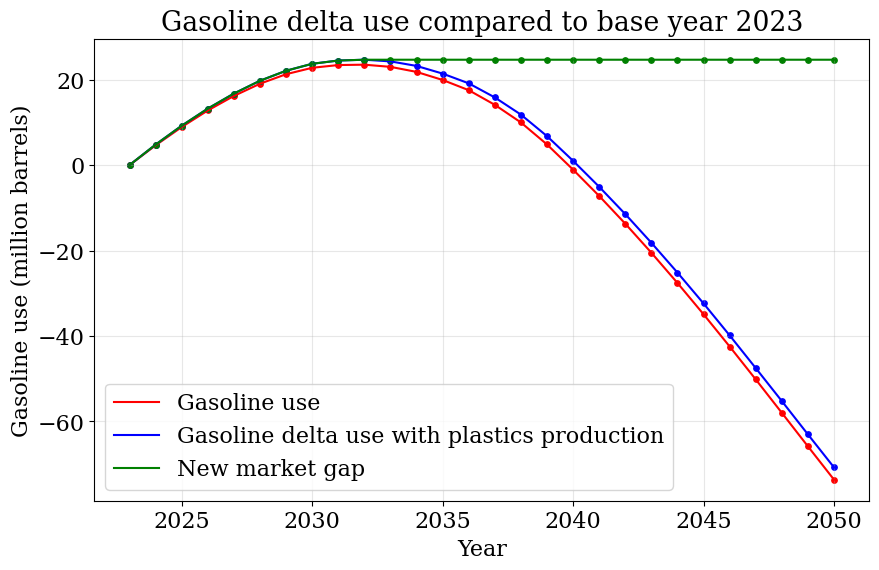

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'y_': [0.0, 4.63, 8.91, 12.79, 16.19, 19.05, 21.28, 22.78, 23.42, 23.51, 23.0, 21.82, 19.93, 17.54, 14.11, 9.98, 4.83, -1.07, -7.23, -13.72, -20.52, -27.6, -34.93, -42.47, -50.18, -58.0, -65.85, -73.65],
        'x_': [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'red',
        'label': 'Gasoline use'
    },
    {
        'y_': [0.0, 4.8, 9.22, 13.23, 16.75, 19.75, 22.09, 23.72, 24.48, 24.67, 24.28, 23.22, 21.42, 19.14, 15.84, 11.82, 6.78, 1.0, -5.08, -11.48, -18.19, -25.17, -32.39, -39.87, -47.53, -55.25, -63.05, -70.78],
        'x_': [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'blue',
        'label': 'Gasoline delta use with plastics production'
    },
    {
        'y_': [0.0, 4.8, 9.22, 13.23, 16.75, 19.75, 22.09, 23.72, 24.48, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67],
        'x_': [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'green',
        'label': 'New market gap'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Gasoline delta use compared to base year 2023')
plt.ylabel('Gasoline use (million barrels)')
plt.xlabel('Year')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()


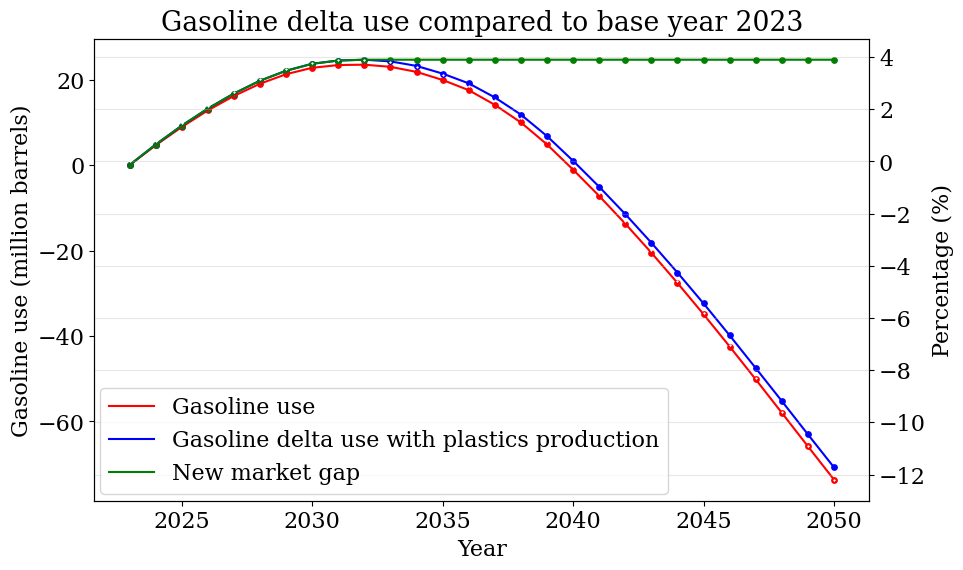

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

# Setting the font to Computer Modern for a LaTeX-like style
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'y_': [0.0, 4.63, 8.91, 12.79, 16.19, 19.05, 21.28, 22.78, 23.42, 23.51, 23.0, 21.82, 19.93, 17.54, 14.11, 9.98, 4.83, -1.07, -7.23, -13.72, -20.52, -27.6, -34.93, -42.47, -50.18, -58.0, -65.85, -73.65],
        'x_': [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'red',
        'label': 'Gasoline use'
    },
    {
        'y_': [0.0, 4.8, 9.22, 13.23, 16.75, 19.75, 22.09, 23.72, 24.48, 24.67, 24.28, 23.22, 21.42, 19.14, 15.84, 11.82, 6.78, 1.0, -5.08, -11.48, -18.19, -25.17, -32.39, -39.87, -47.53, -55.25, -63.05, -70.78],
        'x_': [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'blue',
        'label': 'Gasoline delta use with plastics production'
    },
    {
        'y_': [0.0, 4.8, 9.22, 13.23, 16.75, 19.75, 22.09, 23.72, 24.48, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67, 24.67],
        'x_': [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
        'color': 'green',
        'label': 'New market gap'
    },
]

# Additional data for the secondary y-axis
y2 = [0.0, 0.77, 1.48, 2.12, 2.68, 3.16, 3.53, 3.77, 3.88, 3.9, 3.81, 3.62, 3.3, 2.91, 2.34, 1.65, 0.8, -0.18, -1.2, -2.27, -3.4, -4.57, -5.79, -7.04, -8.31, -9.61, -10.91, -12.2]
x = [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]

# Plot all lines on the same graph with dual y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot data for the first y-axis
for data in datasets:
    ax1.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax1.scatter(data['x_'], data['y_'], color=data['color'], s=15)

ax1.set_xlabel('Year')
ax1.set_ylabel('Gasoline use (million barrels)', color='black')

# Create a second y-axis and plot data on it
ax2 = ax1.twinx()
ax2.plot(x, y2, '*', color='white', markersize=1)
ax2.scatter(x, y2, color='white', s=0)
ax2.set_ylabel('Percentage (%)', color='black')

# Add legend for both y-axes
lines_labels = [ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='center left', bbox_to_anchor=(0.12, 0.21))

# Show plot
plt.title('Gasoline delta use compared to base year 2023')
plt.grid(alpha=0.3)
plt.rcdefaults()
plt.show()



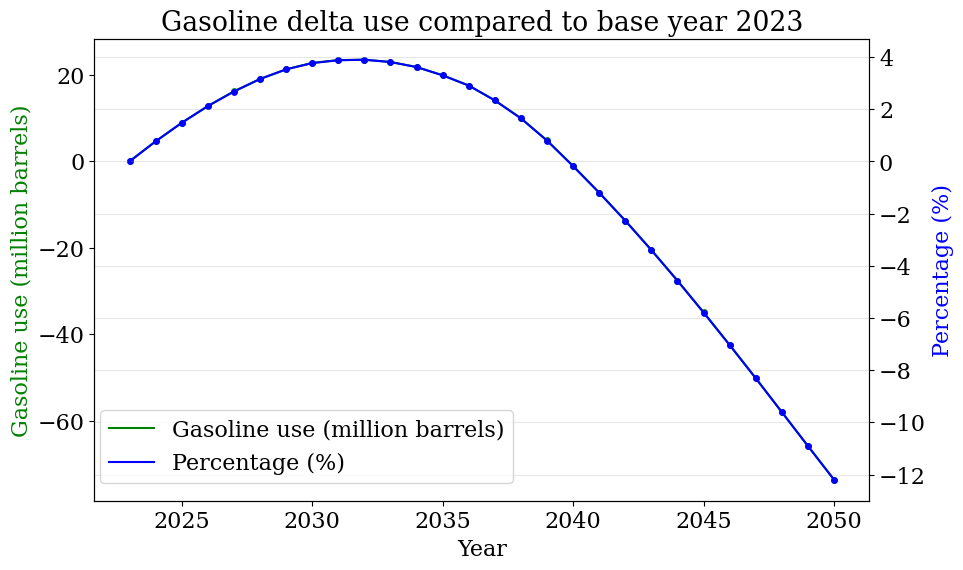

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})
# Data
x = [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]
y1 = [0.0, 4.63, 8.91, 12.79, 16.19, 19.05, 21.28, 22.78, 23.42, 23.51, 23.0, 21.82, 19.93, 17.54, 14.11, 9.98, 4.83, -1.07, -7.23, -13.72, -20.52, -27.6, -34.93, -42.47, -50.18, -58.0, -65.85, -73.65]
y2 = [0.0, 0.77, 1.48, 2.12, 2.68, 3.16, 3.53, 3.77, 3.88, 3.9, 3.81, 3.62, 3.3, 2.91, 2.34, 1.65, 0.8, -0.18, -1.2, -2.27, -3.4, -4.57, -5.79, -7.04, -8.31, -9.61, -10.91, -12.2]

# Plot all lines on the same graph
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot data on the first y-axis
ax1.plot(x, y1, 'g-', label='Gasoline use (million barrels)')
ax1.scatter(x, y1, color='g', s=15)  # Add scatter points
ax1.set_xlabel('Year')
ax1.set_ylabel('Gasoline use (million barrels)', color='g')

# Create a second y-axis and plot data on it
ax2 = ax1.twinx()
ax2.plot(x, y2, 'b-', label='Percentage (%)')
ax2.scatter(x, y2, color='b', s=15)  # Add scatter points
ax2.set_ylabel('Percentage (%)', color='b')

# Show plot
plt.title('Gasoline delta use compared to base year 2023')
plt.grid(alpha=0.3)
fig.legend(loc='center left', bbox_to_anchor=(0.12, 0.2))
plt.rcdefaults()
plt.show()


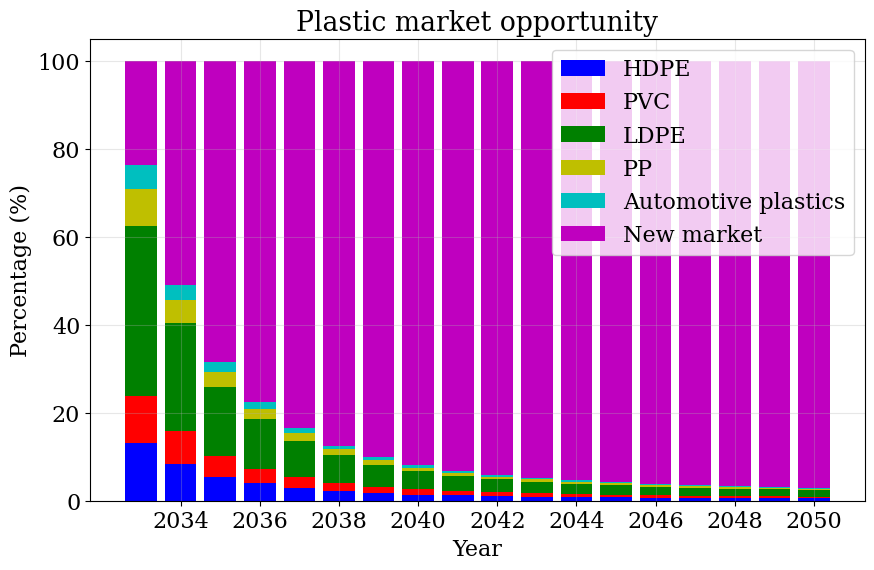

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Data
years = [2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]
HDPE = [0.22, 0.24, 0.26, 0.28, 0.31, 0.32, 0.35, 0.36, 0.39, 0.40, 0.41, 0.42, 0.45, 0.46, 0.48, 0.49, 0.49, 0.50]
PVC = [0.18, 0.21, 0.22, 0.24, 0.25, 0.27, 0.29, 0.30, 0.31, 0.33, 0.34, 0.35, 0.37, 0.38, 0.38, 0.39, 0.41, 0.42]
LDPE = [0.65, 0.70, 0.75, 0.80, 0.88, 0.93, 0.98, 1.06, 1.08, 1.13, 1.18, 1.23, 1.28, 1.31, 1.33, 1.38, 1.41, 1.43]
PP = [0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.29, 0.31, 0.31]
Automotive_plastics = [0.0902, 0.0965, 0.1028, 0.1091, 0.1154, 0.1217, 0.1280, 0.1343, 0.1406, 0.1469, 0.1531, 0.1594, 0.1657, 0.1720, 0.1783, 0.1846, 0.1909, 0.1972]
New_market = [0.40, 1.45, 3.25, 5.53, 8.83, 12.85, 17.89, 23.67, 29.76, 36.16, 42.86, 49.84, 57.07, 64.55, 72.20, 79.93, 87.72, 95.46]

# Calculate percentages
HDPE_percent = []
PVC_percent = []
LDPE_percent = []
PP_percent = []
Automotive_plastics_percent = []
New_market_percent = []

for c1, c2, c3, c4, c5, c6 in zip(HDPE, PVC, LDPE, PP, Automotive_plastics, New_market):
    total = c1 + c2 + c3 + c4 + c5 + c6
    if total != 0:
        HDPE_percent.append(c1 / total * 100)
        PVC_percent.append(c2 / total * 100)
        LDPE_percent.append(c3 / total * 100)
        PP_percent.append(c4 / total * 100)
        Automotive_plastics_percent.append(c5 / total * 100)
        New_market_percent.append(c6 / total * 100)
    else:
        HDPE_percent.append(0)
        PVC_percent.append(0)
        LDPE_percent.append(0)
        PP_percent.append(0)
        Automotive_plastics_percent.append(0)
        New_market_percent.append(0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(years, HDPE_percent, label='HDPE', color='b')
ax.bar(years, PVC_percent, bottom=HDPE_percent, label='PVC', color='r')
ax.bar(years, LDPE_percent, bottom=[i+j for i,j in zip(HDPE_percent, PVC_percent)], label='LDPE', color='g')
ax.bar(years, PP_percent, bottom=[i+j+k for i,j,k in zip(HDPE_percent, PVC_percent, LDPE_percent)], label='PP', color='y')
ax.bar(years, Automotive_plastics_percent, bottom=[i+j+k+l for i,j,k,l in zip(HDPE_percent, PVC_percent, LDPE_percent, PP_percent)], label='Automotive plastics', color='c')
ax.bar(years, New_market_percent, bottom=[i+j+k+l+m for i,j,k,l,m in zip(HDPE_percent, PVC_percent, LDPE_percent, PP_percent, Automotive_plastics_percent)], label='New market', color='m')

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Plastic market opportunity')
ax.set_xticks(years[1::2])  # Display every other year
plt.legend()
plt.grid(alpha=0.3)
plt.rcdefaults()
plt.show()



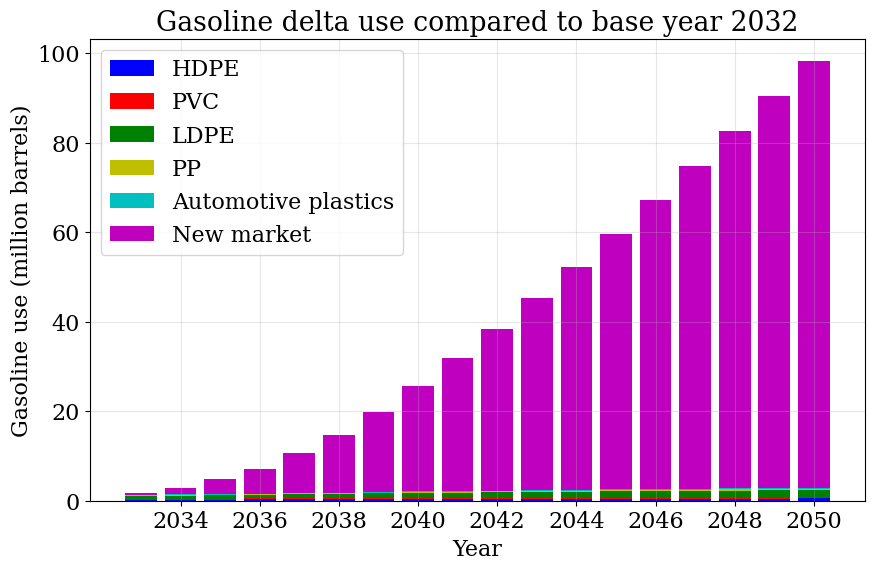

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Data
years = [2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]
HDPE = [0.22, 0.24, 0.26, 0.28, 0.31, 0.32, 0.35, 0.36, 0.39, 0.40, 0.41, 0.42, 0.45, 0.46, 0.48, 0.49, 0.49, 0.50]
PVC = [0.18, 0.21, 0.22, 0.24, 0.25, 0.27, 0.29, 0.30, 0.31, 0.33, 0.34, 0.35, 0.37, 0.38, 0.38, 0.39, 0.41, 0.42]
LDPE = [0.65, 0.70, 0.75, 0.80, 0.88, 0.93, 0.98, 1.06, 1.08, 1.13, 1.18, 1.23, 1.28, 1.31, 1.33, 1.38, 1.41, 1.43]
PP = [0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.29, 0.31, 0.31]
Automotive_plastics = [0.0902, 0.0965, 0.1028, 0.1091, 0.1154, 0.1217, 0.1280, 0.1343, 0.1406, 0.1469, 0.1531, 0.1594, 0.1657, 0.1720, 0.1783, 0.1846, 0.1909, 0.1972]
New_market = [0.40, 1.45, 3.25, 5.53, 8.83, 12.85, 17.89, 23.67, 29.76, 36.16, 42.86, 49.84, 57.07, 64.55, 72.20, 79.93, 87.72, 95.46]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(years, HDPE, label='HDPE', color='b')
ax.bar(years, PVC, bottom=HDPE, label='PVC', color='r')
ax.bar(years, LDPE, bottom=[i+j for i,j in zip(HDPE, PVC)], label='LDPE', color='g')
ax.bar(years, PP, bottom=[i+j+k for i,j,k in zip(HDPE, PVC, LDPE)], label='PP', color='y')
ax.bar(years, Automotive_plastics, bottom=[i+j+k+l for i,j,k,l in zip(HDPE, PVC, LDPE, PP)], label='Automotive plastics', color='c')
ax.bar(years, New_market, bottom=[i+j+k+l+m for i,j,k,l,m in zip(HDPE, PVC, LDPE, PP, Automotive_plastics)], label='New market', color='m')

plt.xlabel('Year')
plt.ylabel('Gasoline use (million barrels)')
plt.title('Gasoline delta use compared to base year 2032')
ax.set_xticks(years[1::2])  # Display every other year
plt.legend()
plt.grid(alpha=0.3)
plt.rcdefaults()
plt.show()


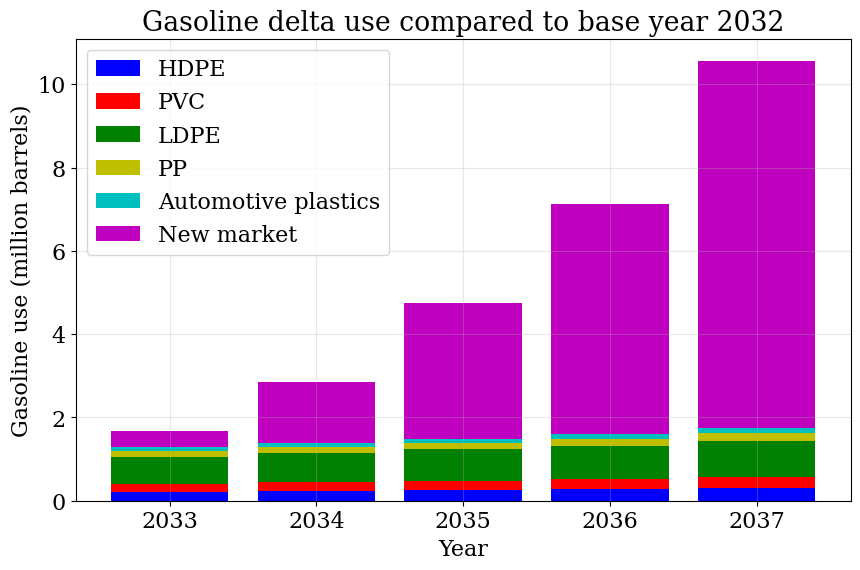

In [80]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Data
years = [2033, 2034, 2035, 2036, 2037]
HDPE = [0.22, 0.24, 0.26, 0.28, 0.31]
PVC = [0.18, 0.21, 0.22, 0.24, 0.25]
LDPE = [0.65, 0.70, 0.75, 0.80, 0.88]
PP = [0.14, 0.15, 0.16, 0.17, 0.18]
Automotive_plastics = [0.0902, 0.0965, 0.1028, 0.1091, 0.1154]
New_market = [0.40, 1.45, 3.25, 5.53, 8.83]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(years, HDPE, label='HDPE', color='b')
ax.bar(years, PVC, bottom=HDPE, label='PVC', color='r')
ax.bar(years, LDPE, bottom=[i+j for i,j in zip(HDPE, PVC)], label='LDPE', color='g')
ax.bar(years, PP, bottom=[i+j+k for i,j,k in zip(HDPE, PVC, LDPE)], label='PP', color='y')
ax.bar(years, Automotive_plastics, bottom=[i+j+k+l for i,j,k,l in zip(HDPE, PVC, LDPE, PP)], label='Automotive plastics', color='c')
ax.bar(years, New_market, bottom=[i+j+k+l+m for i,j,k,l,m in zip(HDPE, PVC, LDPE, PP, Automotive_plastics)], label='New market', color='m')

plt.xlabel('Year')
plt.ylabel('Gasoline use (million barrels)')
plt.title('Gasoline delta use compared to base year 2032')
plt.legend()
plt.grid(alpha=0.3)
plt.rcdefaults()
plt.show()


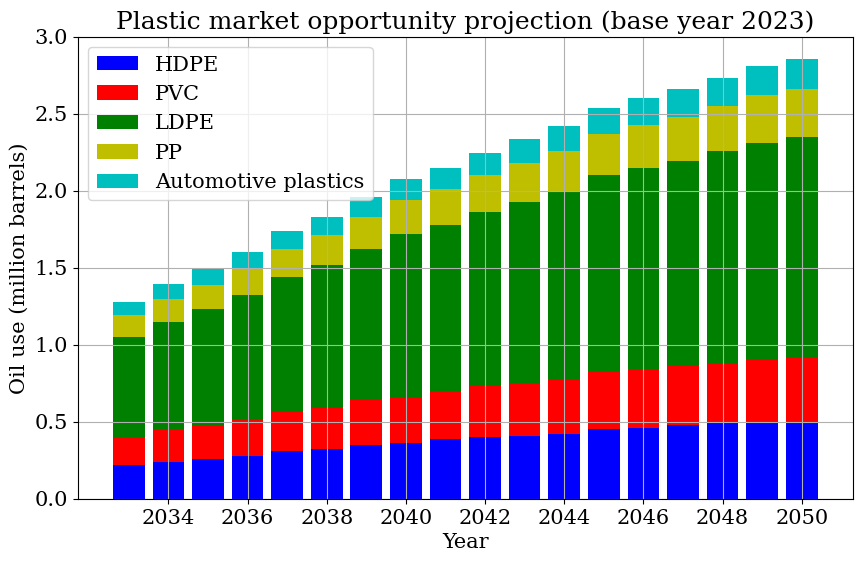

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 15})

# Data
years = [2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050]
HDPE = [0.22, 0.24, 0.26, 0.28, 0.31, 0.32, 0.35, 0.36, 0.39, 0.40, 0.41, 0.42, 0.45, 0.46, 0.48, 0.49, 0.49, 0.50]
PVC = [0.18, 0.21, 0.22, 0.24, 0.25, 0.27, 0.29, 0.30, 0.31, 0.33, 0.34, 0.35, 0.37, 0.38, 0.38, 0.39, 0.41, 0.42]
LDPE = [0.65, 0.70, 0.75, 0.80, 0.88, 0.93, 0.98, 1.06, 1.08, 1.13, 1.18, 1.23, 1.28, 1.31, 1.33, 1.38, 1.41, 1.43]
PP = [0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.29, 0.31, 0.31]
Automotive_plastics = [0.0902, 0.0965, 0.1028, 0.1091, 0.1154, 0.1217, 0.1280, 0.1343, 0.1406, 0.1469, 0.1531, 0.1594, 0.1657, 0.1720, 0.1783, 0.1846, 0.1909, 0.1972]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(years, HDPE, label='HDPE', color='b')
ax.bar(years, PVC, bottom=HDPE, label='PVC', color='r')
ax.bar(years, LDPE, bottom=[i+j for i,j in zip(HDPE, PVC)], label='LDPE', color='g')
ax.bar(years, PP, bottom=[i+j+k for i,j,k in zip(HDPE, PVC, LDPE)], label='PP', color='y')
ax.bar(years, Automotive_plastics, bottom=[i+j+k+l for i,j,k,l in zip(HDPE, PVC, LDPE, PP)], label='Automotive plastics', color='c')

plt.xlabel('Year')
plt.ylabel('Oil use (million barrels)')
plt.title('Plastic market opportunity projection (base year 2023)')
ax.set_xticks(years[1::2])  # Display every other year
plt.legend()
plt.grid(True)
plt.rcdefaults()
plt.show()
